# Task 2: Unemployment Analysis in India (2019 - 2020)
**Objective:** Analyze unemployment rates across Indian states and sectors (Urban vs. Rural) before and during the COVID-19 pandemic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('Unemployment in India.csv')

# Drop completely empty rows
df.dropna(how='all', inplace=True)

# Clean column names by stripping extra spaces
df.columns = df.columns.str.strip()

# Strip spaces from string values
for col in ['Region', 'Frequency', 'Area']:
    df[col] = df[col].astype(str).str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y', errors='coerce')

# Extract Temporal Features
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.month_name()

print("Clean Dataset Shape:", df.shape)
df.head()

Clean Dataset Shape: (740, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September


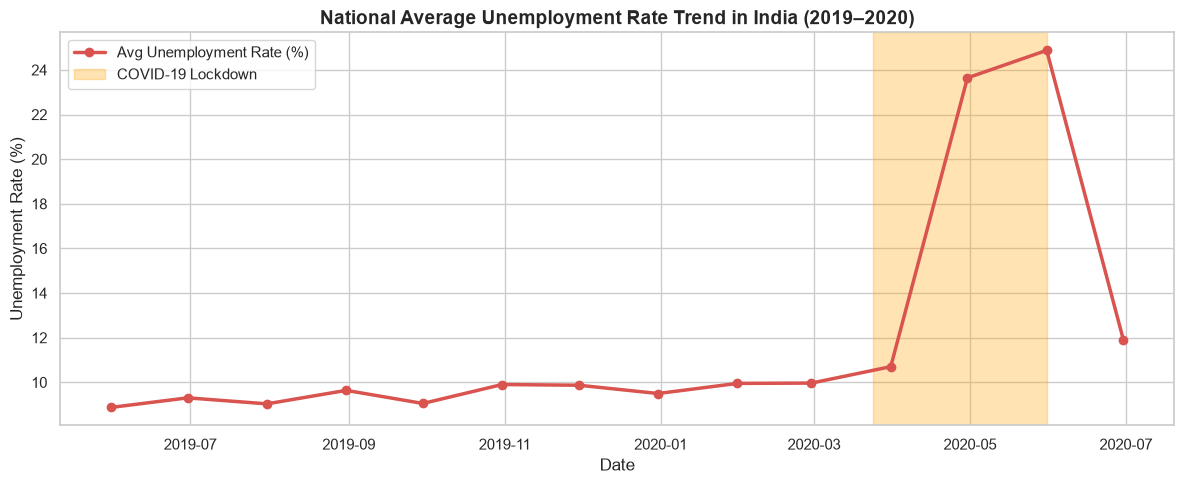

In [3]:
# Aggregate monthly average unemployment rate
monthly_df = df.groupby(['Year', 'Date'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_df['Date'], monthly_df['Estimated Unemployment Rate (%)'], 
         marker='o', color='#d9534f', linewidth=2.5, label='Avg Unemployment Rate (%)')

# Highlight COVID-19 Lockdown Period (March 2020 - May 2020)
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='orange', alpha=0.3, label='COVID-19 Lockdown')

plt.title('National Average Unemployment Rate Trend in India (2019–2020)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

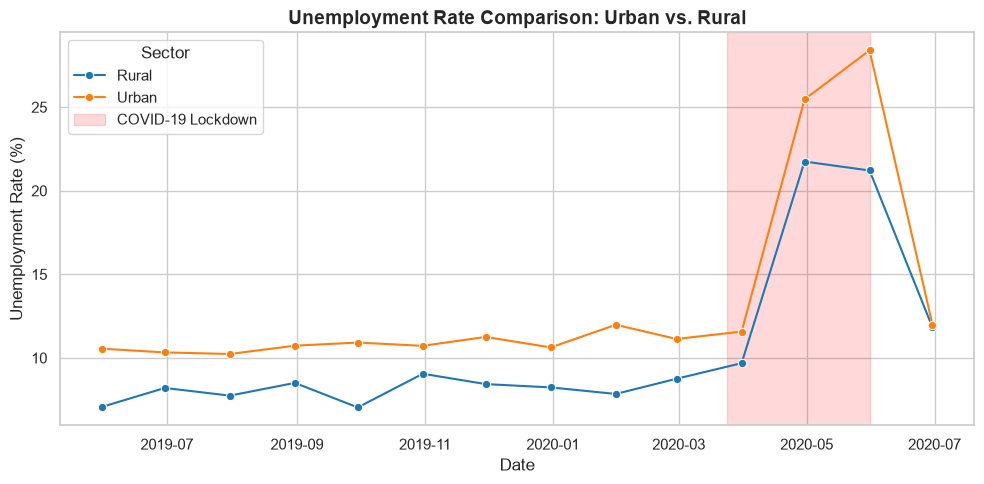

In [4]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', 
             hue='Area', errorbar=None, marker='o', palette=['#1f77b4', '#ff7f0e'])

# Highlight Lockdown Impact
plt.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-05-31'), color='red', alpha=0.15, label='COVID-19 Lockdown')

plt.title('Unemployment Rate Comparison: Urban vs. Rural', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend(title='Sector')
plt.tight_layout()
plt.show()

C:\Users\Rajeev khanduri\AppData\Local\Temp\ipykernel_21456\3348007541.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.head(10).values, y=state_avg.head(10).index, ax=axes[0], palette='Reds_r')
C:\Users\Rajeev khanduri\AppData\Local\Temp\ipykernel_21456\3348007541.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_avg.tail(10).values, y=state_avg.tail(10).index, ax=axes[1], palette='Greens_r')


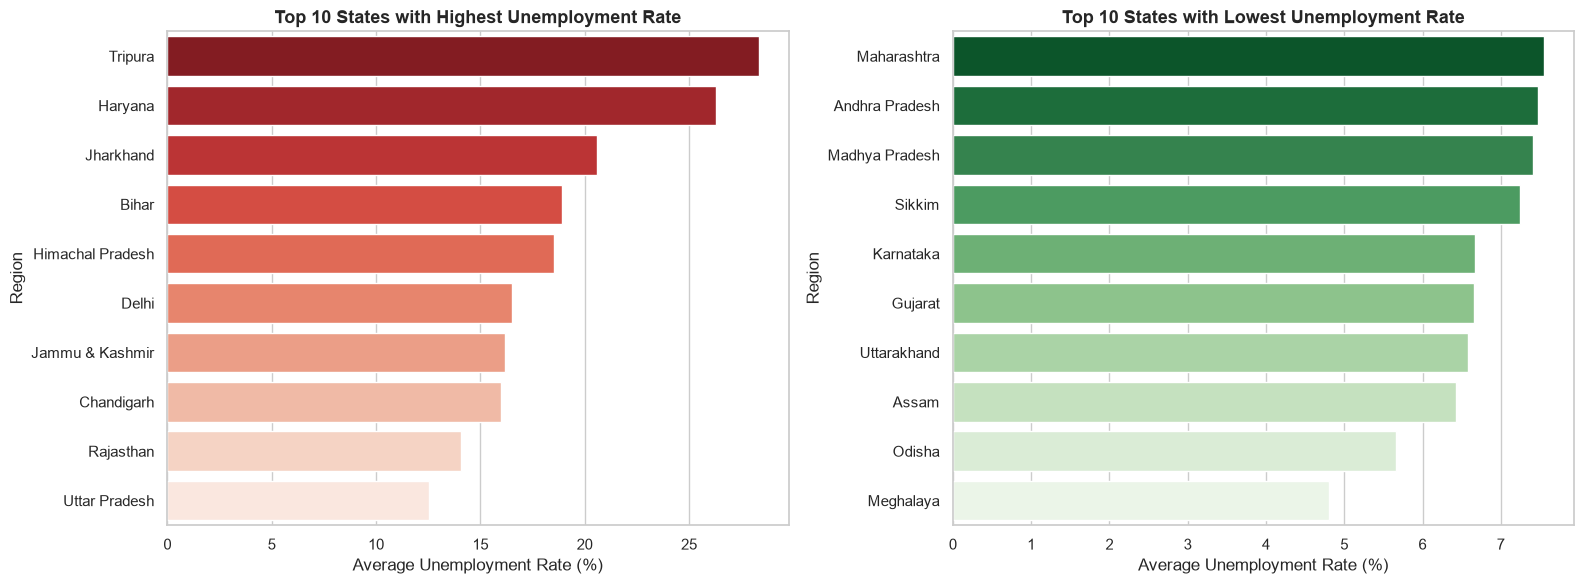

In [5]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Highest
sns.barplot(x=state_avg.head(10).values, y=state_avg.head(10).index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 States with Highest Unemployment Rate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Unemployment Rate (%)')

# Top 10 Lowest
sns.barplot(x=state_avg.tail(10).values, y=state_avg.tail(10).index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 States with Lowest Unemployment Rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

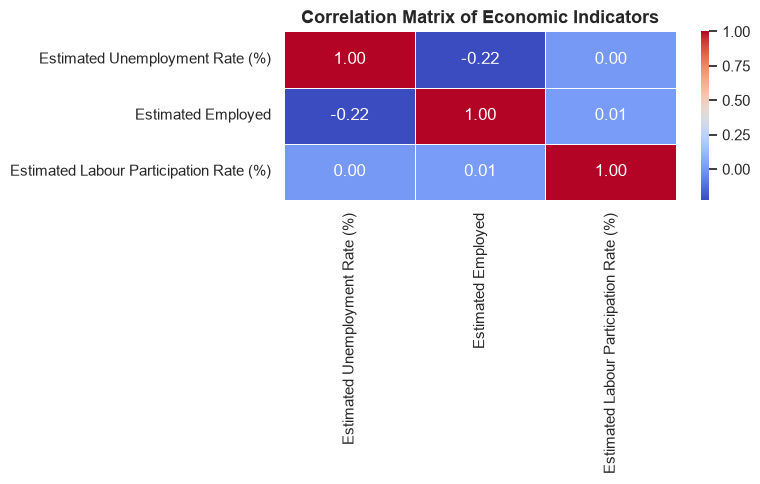

In [6]:
plt.figure(figsize=(8, 5))
numeric_df = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Economic Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()